# Bab 4 — Regression and Prediction

**Tujuan pembelajaran.** memfit serta menafsirkan regresi sederhana dan berganda; mengevaluasi prediksi pada data terpisah; mengodekan kategori; memeriksa confounding, interaksi, outlier, dan residual; membandingkan polinomial, spline, dan GAM.

**Ringkasan bab.** Regresi menghubungkan target numerik dengan prediktor. Fit yang baik pada data latih belum menjamin prediksi baru yang baik. Koefisien bersifat kondisional pada variabel lain dan tidak otomatis kausal. Residual membantu menemukan masalah data dan spesifikasi model. Hubungan yang melengkung dapat dimodelkan dengan basis polinomial/spline atau GAM, dengan risiko overfitting dan ekstrapolasi yang harus diperiksa.

Notebook belajar dan reproduksi edisi kedua (Bruce, Bruce, Gedeck, 2020). Penjelasan ditulis ulang dengan bantuan AI; kode diadaptasi dari repository resmi berlisensi GPL-3.0. Angka dan grafik di bawah berasal dari eksekusi sel. Bagian tambahan diberi label. Gunakan **Restart Kernel → Run All**. Nomor halaman merujuk halaman cetak; nomor PDF = cetak + 18.

**Cara belajar:** baca tujuan setiap bagian, jalankan sel, lalu jelaskan output dengan kalimat sendiri sebelum melihat interpretasinya. Catat mengapa metode tersebut cocok, bukan hanya nama fungsinya.

## Setup dan dataset


| File | Unit observasi dan kolom | Makna |
|---|---|---|
| `LungDisease.csv` | 122 pengamatan; `Exposure`, `PEFR` | Tahun paparan debu kapas dan peak expiratory flow rate; satuan PEFR tidak dicantumkan eksplisit pada CSV/PDF contoh, maka label memakai unit dataset |
| `house_sales.csv` | 22.687 transaksi properti King County | File **tab-separated**; kolom pertama tanpa header menyimpan label baris asal, dibaca sebagai indeks |
| Kolom target | `AdjSalePrice` | Harga penjualan yang disesuaikan (USD); berbeda dari `SalePrice` mentah |
| Prediktor dasar | `SqFtTotLiving`, `SqFtLot` (ft²), `Bathrooms`, `Bedrooms`, `BldgGrade` | Luas bangunan/lot, jumlah kamar mandi/tidur, grade bangunan (ordinal) |
| Prediktor lanjutan | `PropertyType`, `NbrLivingUnits`, `SqFtFinBasement`, `YrBuilt`, `YrRenovated`, `NewConstruction` | Jenis rumah, jumlah unit, luas basement, tahun, indikator konstruksi baru |
| Konteks | `DocumentDate`, `PropertyID`, `ZipCode` | Waktu transaksi, ID properti, dan label lokasi |

Reproduksi model buku memakai seluruh data sesuai contoh; tambahan cross-validation ditandai dan dipisahkan. Data observasional tidak menjamin sebab-akibat. Tidak ada data rumah yang diganti dengan data buatan.


Sumber file: [repository pendamping edisi kedua](https://github.com/gedeck/practical-statistics-for-data-scientists/tree/8a6d3bb6468e979c861d4b37215e1413702dfdfa/data). Commit sumber dan checksum dicatat di `data/manifest.json`. Data bukan hasil simulasi kecuali dinyatakan secara eksplisit.

In [1]:
%matplotlib inline
import os
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from IPython.display import display, Markdown
from importlib.metadata import version

ROOT = Path.cwd()
if not (ROOT / "data/manifest.json").exists():
    raise FileNotFoundError("Buka folder proyek sebagai workspace dan jalankan notebook dari root proyek.")
DATA = ROOT / "data"
SEED = 1
np.random.seed(SEED)
sns.set_theme(style="whitegrid")
plt.rcParams.update({"figure.figsize": (7, 4), "figure.dpi": 110})
pd.set_option("display.max_columns", 25)
print("Python:", sys.version.split()[0], "| Interpreter:", sys.executable)
print("Data:", DATA.relative_to(ROOT))
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import GroupKFold, cross_validate
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import OLSInfluence, variance_inflation_factor
from pygam import LinearGAM, s, l
from patsy import bs
lung=pd.read_csv(DATA / 'LungDisease.csv')
house=pd.read_csv(DATA / 'house_sales.csv',sep='	')
base_features=['SqFtTotLiving','SqFtLot','Bathrooms','Bedrooms','BldgGrade']
target='AdjSalePrice'
assert lung.notna().all().all()
assert house[base_features+[target]].notna().all().all()
print('Lung:',lung.shape,'| House:',house.shape)
print('Baris dengan PropertyID berulang:',int(house.PropertyID.duplicated(keep=False).sum()))
print('Missing values total house:',int(house.isna().sum().sum()))
display(lung.head())
display(house[[target]+base_features].head())

Python: 3.13.5 | Interpreter: /Users/happhify/Telkom/Machine Learning/Practical-Statistics-for-Data-Scientists/.venv/bin/python
Data: data


Lung: (122, 2) | House: (22687, 22)
Baris dengan PropertyID berulang: 3324
Missing values total house: 0


,PEFR,Exposure
0,390,0
1,410,0
2,430,0
3,460,0
4,420,1


,AdjSalePrice,SqFtTotLiving,SqFtLot,Bathrooms,Bedrooms,BldgGrade
1,300805.0,2400,9373,3.00,6,7
2,1076162.0,3764,20156,3.75,4,10
3,761805.0,2060,26036,1.75,4,8
4,442065.0,3200,8618,3.75,5,7
5,297065.0,1720,8620,1.75,4,7


<a id="c4-01"></a>
## Simple Linear Regression

*Acuan: cetak 141; PDF 159. Jenis: Reproduksi Python buku.*

Regresi sederhana memperkirakan target numerik Y berdasarkan satu prediktor X. Korelasi bersifat simetris, sedangkan regresi menetapkan arah prediksi: memperkirakan PEFR dari Exposure berbeda dari memperkirakan Exposure dari PEFR.

Model dapat membantu merangkum asosiasi tetapi tidak membuktikan efek paparan kapas: umur, kebiasaan merokok, dan faktor lain yang tidak tersedia dapat berpengaruh. Data pada buku dipakai sebagai contoh metode, bukan dasar diagnosis individu.

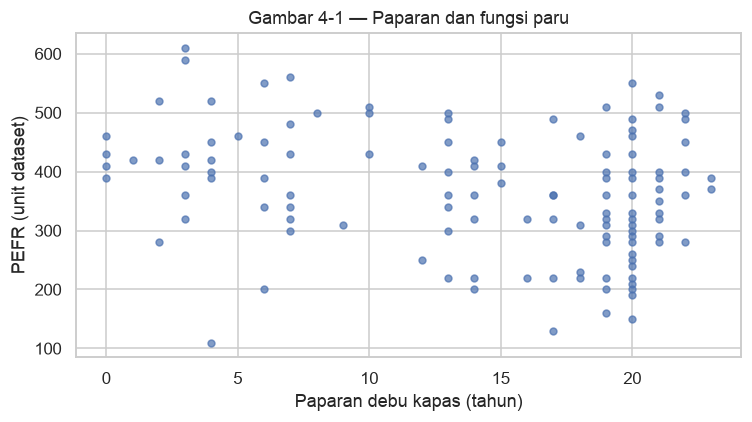

In [2]:
ax=lung.plot.scatter(x='Exposure',y='PEFR',alpha=.7)
ax.set(title='Gambar 4-1 — Paparan dan fungsi paru',xlabel='Paparan debu kapas (tahun)',ylabel='PEFR (unit dataset)')
plt.tight_layout(); plt.show()

**Interpretasi dan catatan belajar.** Sebaran PEFR cukup lebar pada tahun paparan yang sama. Satu garis hanya merangkum kecenderungan rata-rata, bukan menentukan nilai untuk setiap orang.

<a id="c4-02"></a>
## The Regression Equation

*Acuan: cetak 143; PDF 161. Jenis: Reproduksi Python buku.*

Persamaan prediksi adalah $\hat Y=\hat b_0+\hat b_1X$, dengan intercept $\hat b_0$ (prediksi saat X=0) dan slope $\hat b_1$ (perubahan prediksi untuk kenaikan satu unit X). Model observasi menambahkan error: $Y_i=b_0+b_1X_i+\epsilon_i$.

OLS mengasumsikan bentuk mean kondisional sesuai model dan $E[\epsilon\mid X]=0$ untuk interpretasi parameter tak bias. Normalitas error tidak diperlukan untuk menghitung garis OLS, tetapi berperan pada inferensi kecil-sampel tertentu.

Intercept=424.583; slope=-4.185 PEFR/tahun


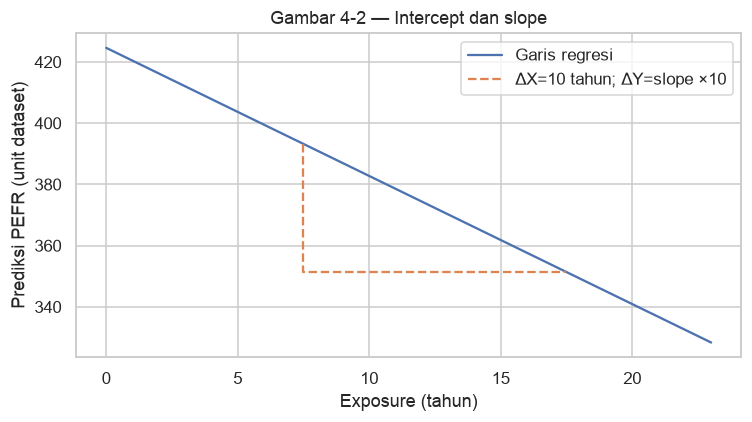

In [3]:
lung_lm=LinearRegression().fit(lung[['Exposure']],lung.PEFR)
print(f'Intercept={lung_lm.intercept_:.3f}; slope={lung_lm.coef_[0]:.3f} PEFR/tahun')
x_grid=pd.DataFrame({'Exposure':np.linspace(0,23,100)})
fig,ax=plt.subplots()
ax.plot(x_grid.Exposure,lung_lm.predict(x_grid),label='Garis regresi')
x_step=pd.DataFrame({'Exposure':[7.5,17.5]}); y_step=lung_lm.predict(x_step)
ax.plot([7.5,7.5,17.5],[y_step[0],y_step[1],y_step[1]],'--',label='ΔX=10 tahun; ΔY=slope ×10')
ax.set(title='Gambar 4-2 — Intercept dan slope',xlabel='Exposure (tahun)',ylabel='Prediksi PEFR (unit dataset)')
ax.legend(); plt.tight_layout(); plt.show()
assert np.isclose(lung_lm.intercept_,424.583,atol=.001)
assert np.isclose(lung_lm.coef_[0],-4.185,atol=.001)

**Interpretasi dan catatan belajar.** Model memprediksi PEFR sekitar 424,583 pada exposure nol dan penurunan sekitar 4,185 unit per tambahan tahun. Ini asosiasi rata-rata pada model satu prediktor, bukan estimasi efek kausal yang telah mengendalikan semua faktor.

<a id="c4-03"></a>
## Fitted Values and Residuals

*Acuan: cetak 146; PDF 164. Jenis: Reproduksi Python buku.*

Fitted value $\hat y_i$ adalah prediksi untuk record yang digunakan memfit model; residual $e_i=y_i-\hat y_i$ adalah selisih aktual dan prediksi. Residual positif berarti model meremehkan Y, negatif berarti melebihkan Y. Residual pada data latih berbeda dari error generalisasi pada observasi baru.

,PEFR,Exposure,fitted,residual
0,390,0,424.582807,-34.582807
1,410,0,424.582807,-14.582807
2,430,0,424.582807,5.417193
3,460,0,424.582807,35.417193
4,420,1,420.398230,-0.398230
5,280,2,416.213654,-136.213654
6,420,2,416.213654,3.786346
7,520,2,416.213654,103.786346


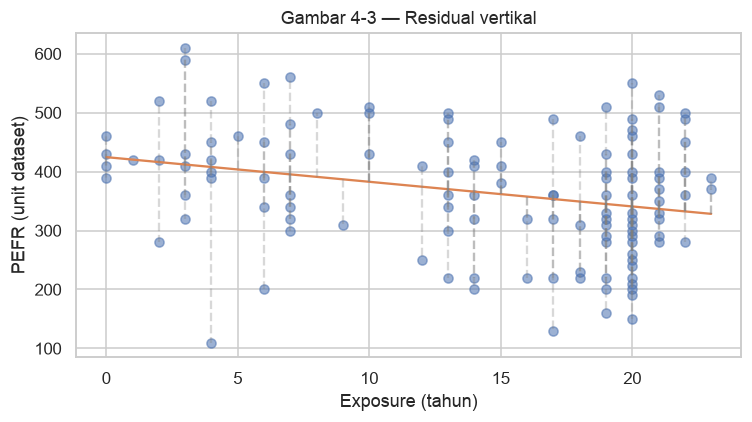

Rata-rata residual: 2.702e-14


In [4]:
lung_fitted=lung_lm.predict(lung[['Exposure']])
lung_residual=lung.PEFR-lung_fitted
display(lung.assign(fitted=lung_fitted,residual=lung_residual).head(8))
fig,ax=plt.subplots()
ax.scatter(lung.Exposure,lung.PEFR,alpha=.55)
ax.plot(x_grid.Exposure,lung_lm.predict(x_grid),color='C1')
ax.vlines(lung.Exposure,lung_fitted,lung.PEFR,colors='gray',linestyles='--',alpha=.3)
ax.set(title='Gambar 4-3 — Residual vertikal',xlabel='Exposure (tahun)',ylabel='PEFR (unit dataset)')
plt.tight_layout(); plt.show()
print(f'Rata-rata residual: {lung_residual.mean():.3e}')

**Interpretasi dan catatan belajar.** Residual rata-rata mendekati nol karena model OLS berintercept, bukan karena model memprediksi setiap orang dengan akurat. Segmen vertikal menunjukkan masih banyak variasi yang belum dijelaskan.

<a id="c4-04"></a>
## Least Squares

*Acuan: cetak 148; PDF 166. Jenis: Teori + verifikasi rumus pada data buku.*

Ordinary least squares memilih koefisien yang meminimalkan $RSS=\sum_i(y_i-\hat y_i)^2$. Kuadrat residual memberi hukuman lebih besar pada kesalahan besar, sehingga outlier berpotensi memengaruhi fit.

Untuk regresi sederhana, $\hat b_1=\sum_i(x_i-\bar x)(y_i-\bar y)/\sum_i(x_i-\bar x)^2$ dan $\hat b_0=\bar y-\hat b_1\bar x$. Penyebut harus positif. Perhitungan tambahan berikut memeriksa bahwa hasil library sesuai rumus, tanpa membalik matriks secara eksplisit.

In [5]:
dx=lung.Exposure-lung.Exposure.mean()
dy=lung.PEFR-lung.PEFR.mean()
slope_manual=(dx*dy).sum()/(dx**2).sum()
intercept_manual=lung.PEFR.mean()-slope_manual*lung.Exposure.mean()
print('Slope rumus:',slope_manual,'| intercept rumus:',intercept_manual)
print('RSS (unit PEFR²):',np.square(lung_residual).sum())
np.testing.assert_allclose([intercept_manual,slope_manual],[lung_lm.intercept_,lung_lm.coef_[0]])

Slope rumus: -4.18457648546144 | intercept rumus: 424.582806573957
RSS (unit PEFR²): 1234764.2857142857


<a id="c4-05"></a>
## Prediction Versus Explanation (Profiling)

*Acuan: cetak 149; PDF 167. Jenis: Teori.*

Untuk **prediction**, fokus pada akurasi target baru dan validasi di luar data latih. Untuk **explanation/profiling**, fokus pada koefisien, mekanisme, dan ketidakpastian hubungan. Model yang memprediksi baik belum tentu memberikan interpretasi kausal yang benar.

Kausalitas memerlukan desain atau asumsi identifikasi tambahan. Misalnya, klik dan penjualan saling berkaitan, tetapi persamaan saja tidak menentukan arah sebab-akibat. Sebaliknya, model penjelasan yang masuk akal masih perlu diuji akurasi prediksinya jika hendak dipakai secara operasional.

<a id="c4-06"></a>
## Multiple Linear Regression

*Acuan: cetak 150; PDF 168. Jenis: Teori.*

Dengan p prediktor, $Y=b_0+\sum_{j=1}^p b_jX_j+\epsilon$. Koefisien $b_j$ adalah perubahan mean prediksi per satu unit $X_j$ **dengan prediktor lain tetap**. Kata linear mengacu pada koefisien; model yang memakai $X^2$ masih linear pada parameter.

Asumsi interpretasi OLS meliputi spesifikasi mean yang memadai, error bermean nol kondisional pada X, dan tidak ada kolinearitas sempurna. Homoskedastisitas dan normalitas menambah dasar untuk standard error/interval klasik, bukan syarat agar algoritme mengeluarkan angka.

<a id="c4-07"></a>
## Example: King County Housing Data

*Acuan: cetak 151; PDF 169. Jenis: Reproduksi Python buku.*

Reproduksi model dasar memakai luas hidup, luas lot, kamar mandi, kamar tidur, dan grade untuk memprediksi `AdjSalePrice`. Pertahankan seluruh 22.687 baris sebagaimana contoh buku; missing value prediktor/target telah diperiksa pada setup. `sklearn` memasang intercept secara default; `statsmodels.OLS` memerlukan kolom konstan yang ditambahkan eksplisit.

In [6]:
house_lm=LinearRegression().fit(house[base_features],house[target])
X_base=sm.add_constant(house[base_features],has_constant='add')
house_ols=sm.OLS(house[target],X_base).fit()
coef_base=pd.Series([house_lm.intercept_,*house_lm.coef_],index=['const']+base_features)
display(coef_base.to_frame('koefisien (USD per unit prediktor)'))
np.testing.assert_allclose(coef_base,house_ols.params,rtol=1e-7,atol=1e-5)

,koefisien (USD per unit prediktor)
const,-521871.368188
SqFtTotLiving,228.830604
SqFtLot,-0.060467
Bathrooms,-19442.840398
Bedrooms,-47769.955185
BldgGrade,106106.963079


**Interpretasi dan catatan belajar.** Koefisien luas hidup sekitar USD228,83 per ft². Pernyataan ini menahan luas lot, grade, dan jumlah kamar tetap; tidak sama dengan keuntungan pasti dari renovasi. Tanda negatif kamar dibahas setelah mempertimbangkan korelasi dan lokasi.

<a id="c4-08"></a>
## Assessing the Model

*Acuan: cetak 153; PDF 171. Jenis: Reproduksi Python buku.*

RMSE $=\sqrt{RSS/n}$ menunjukkan skala kesalahan prediksi (USD). RSE $=\sqrt{RSS/(n-p-1)}$ menyesuaikan derajat bebas. $R^2=1-RSS/\sum_i(y_i-\bar y)^2$ membandingkan model dengan prediksi mean. Pada OLS berintercept di data latih, R² berada pada 0–1; pada data uji dapat negatif.

Adjusted R² $=1-(1-R^2)(n-1)/(n-p-1)$ menambahkan penalti kompleksitas. Statistik t koefisien = estimate/SE; p-value menguji nol kondisional pada model. T besar tidak otomatis berarti manfaat prediksi terbesar atau hubungan kausal. Metrik berikut **in-sample**, belum skor generalisasi.

In [7]:
house_fitted=house_lm.predict(house[base_features])
rmse_train=np.sqrt(mean_squared_error(house[target],house_fitted))
r2_train=r2_score(house[target],house_fitted)
display(pd.Series({'RMSE train (USD)':rmse_train,'RSE (USD)':np.sqrt(house_ols.mse_resid),
                   'R² train':r2_train,'adjusted R²':house_ols.rsquared_adj,
                   'residual df':house_ols.df_resid}).to_frame('nilai'))
print(house_ols.summary())
assert np.isclose(r2_train,.5406,atol=.0001)

,nilai
RMSE train (USD),261220.197437
RSE (USD),261254.746565
R² train,0.540588
adjusted R²,0.540486
residual df,22681.000000


                            OLS Regression Results                            
Dep. Variable:           AdjSalePrice   R-squared:                       0.541
Model:                            OLS   Adj. R-squared:                  0.540
Method:                 Least Squares   F-statistic:                     5338.
Date:                Sun, 27 Sep 2026   Prob (F-statistic):               0.00
Time:                        13:01:44   Log-Likelihood:            -3.1517e+05
No. Observations:               22687   AIC:                         6.304e+05
Df Residuals:                   22681   BIC:                         6.304e+05
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const         -5.219e+05   1.57e+04    -33.342

**Interpretasi dan catatan belajar.** R²≈0,5406 berarti sekitar 54% variasi harga pada data latih dijelaskan model ini. RMSE sekitar USD261 ribu masih besar; jangan menyebut “akurasi 54%”. Harga ekstrem dapat sangat memengaruhi RMSE. Condition number pada ringkasan mengingatkan perbedaan skala/korelasi prediktor, yang diperiksa pada bagian multicollinearity.

<a id="c4-09"></a>
## Cross-Validation

*Acuan: cetak 155; PDF 173. Jenis: Tambahan Python algoritme cross-validation buku.*

K-fold cross-validation melatih pada K−1 fold dan menilai pada fold sisanya, lalu mengulang sampai semua fold menjadi validation. Pemilihan fitur, normalisasi, dan pengodean yang belajar dari target harus dilakukan **di dalam fold training**. Jika memilih model berdasarkan CV lalu melaporkan skor yang sama, tetap ada bias seleksi; holdout final atau nested CV diperlukan untuk penilaian akhir.

**Tambahan implementasi dari algoritme buku:** 5-fold `GroupKFold` berdasarkan `PropertyID` mencegah transaksi properti yang sama tersebar ke train dan validation. Ini validasi antarproperti pada periode historis, belum validasi prediksi masa depan. Tidak ada `ZipGroup` berbasis target yang dihitung sebelum CV ini.

In [8]:
cv=GroupKFold(n_splits=5)
cv_splits=list(cv.split(house[base_features],house[target],groups=house.PropertyID))
for train_idx,test_idx in cv_splits:
    assert set(house.PropertyID.iloc[train_idx]).isdisjoint(house.PropertyID.iloc[test_idx])
cv_result=cross_validate(LinearRegression(),house[base_features],house[target],cv=cv_splits,
                        scoring={'mse':'neg_mean_squared_error','r2':'r2'},n_jobs=1)
cv_table=pd.DataFrame({'fold':np.arange(1,6),'RMSE validation (USD)':np.sqrt(-cv_result['test_mse']),
                       'R² validation':cv_result['test_r2']})
display(cv_table)
print('Mean RMSE validation:',cv_table['RMSE validation (USD)'].mean())
print('SD RMSE antar-fold:',cv_table['RMSE validation (USD)'].std())

,fold,RMSE validation (USD),R² validation
0,1,267753.617825,0.502026
1,2,240809.000839,0.588865
2,3,244830.182548,0.562918
3,4,274759.373734,0.526691
4,5,277070.723981,0.523019


Mean RMSE validation: 261044.57978530094
SD RMSE antar-fold: 17046.476141306503


**Interpretasi dan catatan belajar.** Skor tiap fold menggambarkan sensitivitas terhadap pembagian data. Mean RMSE fold tidak sama dengan RMSE gabungan seluruh prediksi jika ukuran fold berbeda. Nilai in-sample sebelumnya tidak boleh dipakai sebagai klaim kemampuan memprediksi transaksi masa depan.

<a id="c4-10"></a>
## Model Selection and Stepwise Regression

*Acuan: cetak 156; PDF 174. Jenis: Reproduksi maksud analisis; helper stepwise lokal.*

Menambah fitur selalu dapat menurunkan RSS latih, sehingga memilih model hanya dari R² latih mengundang overfitting. AIC menyeimbangkan fit dan kompleksitas. Hingga konstanta yang sama antar-model Gaussian, $AIC=n\log(RSS/n)+2k$, dengan k jumlah parameter yang dibandingkan (di sini termasuk intercept; parameter varians tambahan memberi konstanta yang sama). Nilai lebih kecil lebih baik untuk perbandingan pada **data dan target yang sama**.

**Forward selection** menambah fitur; **backward elimination** mengurangi; **stepwise** mengevaluasi keduanya. All-subsets mencoba seluruh kombinasi dan cepat menjadi mahal. AICc mengoreksi sampel kecil, BIC memberi penalti k log(n), dan Mallows Cp merupakan ukuran terkait. Ridge menyusutkan koefisien dengan penalti L2, Lasso dengan L1 dan bisa menjadi nol; bagian kode Lasso tambahan upstream tidak termasuk cakupan reproduksi wajib PDF.

**Adaptasi dependency:** fungsi stepwise ditulis transparan memakai `LinearRegression`, menggantikan helper `dmba` agar tidak memasang paket tambahan. Kriterianya tetap AIC Gaussian dan penambahan/penghapusan satu kolom. Dummy dipilih per kolom seperti versi Python, sedangkan R dapat memilih faktor sebagai kelompok; jalur pencarian bisa berbeda dan bukan pencarian optimum global.

In [9]:
full_features=base_features+['PropertyType','NbrLivingUnits','SqFtFinBasement',
                             'YrBuilt','YrRenovated','NewConstruction']
X_full=pd.get_dummies(house[full_features],drop_first=True,dtype=int).astype(float)
y_house=house[target]
full_ols=sm.OLS(y_house,sm.add_constant(X_full,has_constant='add')).fit()

def fit_aic(columns):
    if columns:
        model=LinearRegression().fit(X_full[columns],y_house)
        prediction=model.predict(X_full[columns])
    else:
        model=None
        prediction=np.repeat(y_house.mean(),len(y_house))
    rss=np.square(y_house.to_numpy()-prediction).sum()
    score=len(y_house)*np.log(rss/len(y_house))+2*(len(columns)+1)
    return score,model

selected=[]
current_aic,best_model=fit_aic(selected)
selection_history=[{'langkah':'intercept saja','AIC tanpa konstanta':current_aic,'fitur':0}]
while True:
    candidates=[]
    for col in X_full.columns:
        cols=selected+[col] if col not in selected else [c for c in selected if c!=col]
        score,model=fit_aic(cols)
        candidates.append((score,col,cols,model))
    score,col,cols,model=min(candidates,key=lambda x:x[0])
    if score>=current_aic-1e-8:
        break
    action='tambah' if col not in selected else 'hapus'
    selected,current_aic,best_model=cols,score,model
    selection_history.append({'langkah':f'{action} {col}','AIC tanpa konstanta':score,'fitur':len(cols)})
display(pd.DataFrame(selection_history))
display(pd.Series([best_model.intercept_,*best_model.coef_],index=['const']+selected).to_frame('stepwise'))
display(pd.DataFrame({'model':['dasar','full','stepwise'],
                      'jumlah prediktor':[len(base_features),len(X_full.columns),len(selected)],
                      'RMSE train':[rmse_train,np.sqrt(full_ols.mse_resid*full_ols.df_resid/len(house)),
                                    np.sqrt(mean_squared_error(y_house,best_model.predict(X_full[selected])))]}))
print('Dikeluarkan:',[c for c in X_full if c not in selected])

,langkah,AIC tanpa konstanta,fitur
0,intercept saja,583603.405121,0
1,tambah SqFtTotLiving,568628.436532,1
2,tambah BldgGrade,566408.818988,2
3,tambah YrBuilt,563845.377807,3
4,tambah Bedrooms,563399.238445,4
5,tambah Bathrooms,563217.289106,5
6,tambah PropertyType_Townhouse,563140.736998,6
7,tambah SqFtFinBasement,563140.163055,7
8,tambah PropertyType_Single Family,563140.059566,8


,stepwise
const,6.178645e+06
SqFtTotLiving,1.992776e+02
BldgGrade,1.371596e+05
YrBuilt,-3.565425e+03
Bedrooms,-5.194738e+04
Bathrooms,4.239616e+04
PropertyType_Townhouse,8.447916e+04
SqFtFinBasement,7.046975e+00
PropertyType_Single Family,2.291206e+04


,model,jumlah prediktor,RMSE train
0,dasar,5,261220.197437
1,full,12,245393.775880
2,stepwise,8,245407.906642


Dikeluarkan: ['SqFtLot', 'NbrLivingUnits', 'YrRenovated', 'NewConstruction']


**Interpretasi dan catatan belajar.** Riwayat menunjukkan penurunan AIC sampai tidak ada satu langkah yang memperbaiki skor. Hasil seleksi bukan bukti bahwa fitur terbuang tidak berguna secara universal. P-value sesudah pemilihan pada data yang sama juga tidak memiliki interpretasi sederhana seolah model ditetapkan sejak awal.

<a id="c4-11"></a>
## Weighted Regression

*Acuan: cetak 159; PDF 177. Jenis: Reproduksi Python buku.*

Weighted least squares meminimalkan $\sum_iw_i(y_i-\hat y_i)^2$. Bobot bisa mencerminkan presisi (inverse variance), banyak kasus yang diwakili, atau relevansi. Contoh buku memberi transaksi baru bobot lebih besar dengan $w=\mathrm{Year}-2005$.

Bobot berbasis tahun merupakan pilihan model, bukan otomatis inverse variance yang terestimasi. Model tertimbang tidak dijamin lebih akurat pada semua periode. Semua bobot harus nonnegatif dan setidaknya ada yang positif.

In [10]:
house['Year']=pd.to_datetime(house.DocumentDate).dt.year
house['Weight']=house.Year-2005
assert (house.Weight>=0).all() and house.Weight.sum()>0
weighted=LinearRegression().fit(house[base_features],house[target],sample_weight=house.Weight)
coef_weighted=pd.Series([weighted.intercept_,*weighted.coef_],index=['const']+base_features)
display(pd.DataFrame({'OLS':coef_base,'weighted':coef_weighted}))
by_year=pd.DataFrame({'Year':house.Year,'abs_error_OLS':np.abs(house[target]-house_fitted),
                     'abs_error_weighted':np.abs(house[target]-weighted.predict(house[base_features]))})
display(by_year.groupby('Year')[['abs_error_OLS','abs_error_weighted']].mean().round(2))

,OLS,weighted
const,-521871.368188,-584189.329446
SqFtTotLiving,228.830604,245.024089
SqFtLot,-0.060467,-0.292415
Bathrooms,-19442.840398,-26085.970109
Bedrooms,-47769.955185,-53608.876436
BldgGrade,106106.963079,115242.434726


,abs_error_OLS,abs_error_weighted
Year,,
2006,140540.30,146557.45
2007,147747.58,152848.52
2008,142086.91,146360.41
2009,147016.72,151182.92
2010,163267.67,166364.48
2011,169937.39,172950.88
2012,169506.67,171874.42
2013,203659.78,206242.20
2014,184452.84,186668.57


**Interpretasi dan catatan belajar.** Koefisien luas hidup meningkat pada model tertimbang. Tabel error per tahun masih in-sample; perubahan itu menunjukkan prioritas bobot, bukan bukti validasi bahwa model terbaru pasti lebih baik.

<a id="c4-12"></a>
## Prediction Using Regression

*Acuan: cetak 161; PDF 179. Jenis: Demonstrasi tambahan API prediksi.*

Prediksi baru harus menyediakan fitur dengan definisi, skala, dan pengodean yang sama seperti saat training. Model sebaiknya digunakan pada populasi dan rentang kombinasi fitur yang terwakili. Titik yang masing-masing fiturnya berada dalam rentang marginal tetap bisa merupakan kombinasi yang tidak pernah muncul.

Berikut contoh cara memanggil `predict` pada tiga baris. Baris tersebut sengaja berasal dari data latih untuk mendemonstrasikan API, bukan test set baru.

In [11]:
display(house[[target]+base_features].head(3).assign(prediksi_USD=house_lm.predict(house[base_features].head(3))))

,AdjSalePrice,SqFtTotLiving,SqFtLot,Bathrooms,Bedrooms,BldgGrade,prediksi_USD
1,300805.0,2400,9373,3.00,6,7,4.245558e+05
2,1076162.0,3764,20156,3.75,4,10,1.135307e+06
3,761805.0,2060,26036,1.75,4,8,5.716963e+05


<a id="c4-13"></a>
## The Dangers of Extrapolation

*Acuan: cetak 161; PDF 179. Jenis: Padanan Python contoh naratif buku.*

Buku memakai kasus lahan kosong 5.000 ft²: semua fitur bangunan bernilai nol. Model dilatih pada properti dengan bangunan sehingga kombinasi ini tidak terwakili. Output negatif merupakan peringatan domain, bukan harga tanah yang valid.

In [12]:
vacant=pd.DataFrame([{'SqFtTotLiving':0,'SqFtLot':5000,'Bathrooms':0,'Bedrooms':0,'BldgGrade':0}])
print(f'Prediksi lahan kosong 5.000 ft²: USD {house_lm.predict(vacant[base_features])[0]:,.2f}')

Prediksi lahan kosong 5.000 ft²: USD -522,173.70


**Interpretasi dan catatan belajar.** Jangan memperbaiki masalah hanya dengan memotong harga menjadi nol. Model/ruang data perlu disesuaikan dengan objek lahan kosong. Ini padanan Python contoh hitung naratif buku.

<a id="c4-14"></a>
## Confidence and Prediction Intervals

*Acuan: cetak 161; PDF 179. Jenis: Tambahan Python algoritme bootstrap dan interval buku.*

Confidence interval koefisien mengukur ketidakpastian parameter; CI mean response mengukur ketidakpastian rata-rata respons pada X tertentu. Prediction interval untuk **satu observasi baru** menambahkan variasi individual, sehingga biasanya lebih lebar.

Algoritme bootstrap buku: resample seluruh baris bersama target, fit ulang, dan simpan koefisien/prediksi. Untuk prediction interval tambahkan satu residual acak dari fit awal. **Tambahan implementasi algoritme** berikut memakai data lung dan prediksi Exposure=10 tahun, B=1.000. Residual bootstrap sederhana mengasumsikan error cukup homogen/independen; jika heteroskedastik, residual acak global dapat menghasilkan interval keliru.

Formula `statsmodels.get_prediction` untuk rumah juga ditampilkan. Interval klasik rumah bersifat ilustratif karena diagnostik nanti menunjukkan pelanggaran distribusi residual.

In [13]:
new_x=pd.DataFrame({'Exposure':[10]})
rng_interval=np.random.default_rng(SEED)
boot_coef=[]; boot_fit=[]; boot_prediction=[]
for _ in range(1000):
    sample=lung.iloc[rng_interval.integers(0,len(lung),len(lung))]
    fitted_model=LinearRegression().fit(sample[['Exposure']],sample.PEFR)
    mu=fitted_model.predict(new_x)[0]
    boot_coef.append([fitted_model.intercept_,fitted_model.coef_[0]])
    boot_fit.append(mu)
    boot_prediction.append(mu+rng_interval.choice(lung_residual.to_numpy()))
display(pd.DataFrame(np.quantile(boot_coef,[.025,.975],axis=0),
                     index=['2,5%','97,5%'],columns=['intercept','slope']))
display(pd.DataFrame([np.quantile(boot_fit,[.025,.975]),np.quantile(boot_prediction,[.025,.975])],
                     index=['CI mean PEFR 95%','PI individu PEFR 95%'],columns=['lower','upper']))
display(house_ols.get_prediction(X_base.head(3)).summary_frame(alpha=.05))

,intercept,slope
"2,5%",384.041533,-6.779773
"97,5%",461.090271,-1.687000


,lower,upper
CI mean PEFR 95%,361.484249,402.714188
PI individu PEFR 95%,177.031902,563.547490


,mean,mean_se,mean_ci_lower,mean_ci_upper,obs_ci_lower,obs_ci_upper
1,4.245558e+05,6457.166823,4.118993e+05,4.372123e+05,-87677.791573,9.367894e+05
2,1.135307e+06,4301.371581,1.126876e+06,1.143738e+06,623160.791874,1.647454e+06
3,5.716963e+05,3354.324362,5.651216e+05,5.782710e+05,59576.847881,1.083816e+06


**Interpretasi dan catatan belajar.** Bandingkan lebar CI mean dan PI individu pada output. Jumlah data training yang besar dapat membuat mean sangat presisi sambil menyisakan error individual yang besar. CI sempit bukan jaminan prediksi satu rumah atau satu individu tepat.

<a id="c4-15"></a>
## Factor Variables in Regression

*Acuan: cetak 163; PDF 181. Jenis: Teori.*

Regresi numerik membutuhkan pengodean variabel kategorikal. Reference/treatment coding memakai satu kategori baseline; koefisien kategori lain adalah perbedaan kondisional terhadap baseline. Deviation/sum coding membandingkan kategori terhadap pusat bersama. One-hot menyimpan indikator semua level dan sesuai untuk beberapa model, tetapi bersama intercept menimbulkan redundansi pada OLS.

<a id="c4-16"></a>
## Dummy Variables Representation

*Acuan: cetak 164; PDF 182. Jenis: Reproduksi Python; dtype eksplisit.*

`PropertyType` mempunyai tiga level: Multiplex, Single Family, Townhouse. Dengan baseline Multiplex dan intercept, cukup dua dummy. `dtype=int` ditentukan agar hasil tidak bergantung pada default boolean versi pandas, lalu input OLS dijadikan float bila diperlukan.

Interpretasi membandingkan tipe properti dengan prediktor lain tetap. Jangan menyimpulkan bahwa mengubah nama kategori mengubah harga secara kausal.

In [14]:
display(pd.get_dummies(house.PropertyType,dtype=int).head(6))
X_factor=pd.get_dummies(house[base_features+['PropertyType']],drop_first=True,dtype=int).astype(float)
factor_lm=LinearRegression().fit(X_factor,house[target])
coef_factor=pd.Series([factor_lm.intercept_,*factor_lm.coef_],index=['const']+list(X_factor.columns))
display(coef_factor.to_frame('model dengan PropertyType'))

,Multiplex,Single Family,Townhouse
1,1,0,0
2,0,1,0
3,0,1,0
4,0,1,0
5,0,1,0
6,0,0,1


,model dengan PropertyType
const,-446841.366312
SqFtTotLiving,223.373629
SqFtLot,-0.070368
Bathrooms,-15979.013473
Bedrooms,-50889.732185
BldgGrade,109416.305161
PropertyType_Single Family,-84678.216295
PropertyType_Townhouse,-115121.979216


**Interpretasi dan catatan belajar.** Koefisien kategori relatif terhadap Multiplex dapat tampak tidak intuitif karena lokasi belum dimasukkan. Output Townhouse sekitar −USD115 ribu; prosa buku yang menyebut lebih dari USD150 ribu tidak konsisten dengan tabel koefisiennya. Notebook mengikuti nilai terhitung.

<a id="c4-17"></a>
## Factor Variables with Many Levels

*Acuan: cetak 167; PDF 185. Jenis: Reproduksi Python dengan groupby modern.*

Kode pos memiliki banyak level, sebagian hanya sedikit transaksi. Terlalu banyak dummy dapat menghasilkan parameter yang tidak stabil. Contoh buku merangkum residual model awal per kode pos, mengurutkan median residual, lalu membagi kode pos menjadi lima grup.

Implementasi `groupby.agg` mengganti pola `groupby.apply` lama tanpa mengubah tujuan. `qcut(cum_count,5)` mengikuti Python pendamping. Metode R `ntile` dapat membagi sedikit berbeda, sehingga koefisien berikutnya tidak harus identik dengan R.

**Batas penggunaan:** ZipGroup dibuat menggunakan target seluruh data untuk mereproduksi analisis deskriptif buku. Ini target encoding yang menyebabkan leakage bila digunakan untuk mengevaluasi data yang ikut membentuk grup. Jangan memakainya dalam CV sebelumnya atau mengklaim skor out-of-sample; untuk deployment, fit mapping di training/fold saja dan siapkan fallback kode pos baru.

In [15]:
display(house.ZipCode.value_counts().rename('jumlah transaksi').to_frame().T)
zip_residual=pd.DataFrame({'ZipCode':house.ZipCode,'residual':house[target]-house_fitted})
zip_groups=(zip_residual.groupby('ZipCode').agg(count=('residual','size'),median_residual=('residual','median'))
            .sort_values('median_residual').reset_index())
zip_groups['cum_count']=zip_groups['count'].cumsum()
zip_groups['ZipGroup']=pd.qcut(zip_groups.cum_count,5,labels=False)
house=house.join(zip_groups.set_index('ZipCode')[['ZipGroup']],on='ZipCode')
house['ZipGroup']=house.ZipGroup.astype('category')
display(zip_groups.head(10))
display(zip_groups.groupby('ZipGroup').agg(kode_pos=('ZipCode','size'),transaksi=('count','sum')))
print('Jumlah kode pos:',house.ZipCode.nunique())

ZipCode,98038,98103,98042,98115,98117,98052,98034,98033,98059,98074,98053,98118,...,98039,98148,98051,98024,98354,98050,98057,98288,98224,98068,98113,98043
jumlah transaksi,788,671,641,620,619,614,575,517,513,502,499,492,...,47,40,32,31,9,7,4,4,3,1,1,1


,ZipCode,count,median_residual,cum_count,ZipGroup
0,98057,4,-537321.644462,4,0
1,98043,1,-307661.343614,5,0
2,98092,289,-193569.183599,294,0
3,98038,788,-150066.477035,1082,0
4,98051,32,-142352.869593,1114,0
5,98023,455,-141201.501535,1569,0
6,98003,241,-131528.875324,1810,0
7,98354,9,-131442.275598,1819,0
8,98075,388,-130676.717860,2207,0
9,98031,308,-129211.854226,2515,0


,kode_pos,transaksi
ZipGroup,,
0,16,4733
1,16,3602
2,16,4607
3,16,4279
4,16,5466


Jumlah kode pos: 80


**Interpretasi dan catatan belajar.** Grup merangkum kecenderungan harga yang belum dijelaskan fitur bangunan. Ini bukan pembagian wilayah alami atau clustering tanpa target. Label Python 0–4 berbeda penomoran dari R 1–5.

<a id="c4-18"></a>
## Ordered Factor Variables

*Acuan: cetak 169; PDF 187. Jenis: Teori.*

Ordinal memiliki urutan seperti grade bangunan. Memakai `BldgGrade` sebagai angka, seperti buku, menyiratkan kenaikan satu grade berpengaruh linear dan sama di semua tingkatan. Urutan tidak otomatis menjamin jarak ekonomi setara. Alternatif kategori atau efek nonlinear dapat diuji bila asumsi itu tidak masuk akal.

Contoh arti level buku: 1 cabin, 2 substandard, 5 fair, 10 very good, 12 luxury, 13 mansion. Urutan dipertahankan dalam model numerik, tetapi interpretasi slope tetap bersyarat pada pendekatan tersebut.

<a id="c4-19"></a>
## Interpreting the Regression Equation

*Acuan: cetak 169; PDF 187. Jenis: Teori.*

Koefisien dipengaruhi prediktor yang disertakan, skala variabel, dan kelompok referensi. Tanda koefisien yang berlawanan intuisi adalah alasan menyelidiki spesifikasi, bukan langsung menghapus variabel. Tiga sumber masalah utama pada contoh rumah: korelasi prediktor, variabel lokasi yang dihilangkan, dan interaksi luas–lokasi.

<a id="c4-20"></a>
## Correlated Predictors

*Acuan: cetak 170; PDF 188. Jenis: Reproduksi Python buku.*

Rumah lebih besar biasanya mempunyai lebih banyak kamar. Dengan luas tetap, menambah jumlah kamar berarti kamar rata-rata lebih kecil; koefisien Bedrooms negatif tidak sama dengan pernyataan “rumah dengan lebih banyak kamar selalu lebih murah”. Model reduced buku menghapus luas hidup, basement, dan kamar mandi sehingga Bedrooms mengambil sebagian peran proxy ukuran rumah.

In [16]:
reduced_features=['Bedrooms','BldgGrade','PropertyType','YrBuilt']
X_reduced=pd.get_dummies(house[reduced_features],drop_first=True,dtype=int).astype(float)
reduced_lm=LinearRegression().fit(X_reduced,house[target])
coef_reduced=pd.Series(reduced_lm.coef_,index=X_reduced.columns)
display(house[['SqFtTotLiving','Bedrooms','Bathrooms']].corr())
display(pd.DataFrame({'dasar':coef_base,'stepwise':pd.Series(best_model.coef_,index=selected),
                      'reduced':coef_reduced}).loc[['Bedrooms','BldgGrade']])

,SqFtTotLiving,Bedrooms,Bathrooms
SqFtTotLiving,1.000000,0.600317,0.764155
Bedrooms,0.600317,1.000000,0.537998
Bathrooms,0.764155,0.537998,1.000000


,dasar,stepwise,reduced
Bedrooms,-47769.955185,-51947.383674,27150.537230
BldgGrade,106106.963079,137159.560226,248997.793662


**Interpretasi dan catatan belajar.** Bedrooms menjadi positif ketika fitur ukuran lain dihapus. Pergeseran ini memperlihatkan sifat kondisional koefisien. Prediksi dapat tetap berguna meskipun pembagian kontribusi ke prediktor berkorelasi sulit ditafsirkan.

<a id="c4-21"></a>
## Multicollinearity

*Acuan: cetak 172; PDF 190. Jenis: Teori + diagnostik tambahan pada data buku.*

Kolinearitas sempurna berarti satu kolom merupakan kombinasi linear kolom lain, sehingga koefisien OLS tidak unik. Hampir kolinear menyebabkan estimasi sensitif dan SE membesar. Contoh: duplikasi kolom, semua dummy plus intercept, atau dua fitur hampir sama.

**Tambahan diagnostik** variance inflation factor $VIF_j=1/(1-R_j^2)$ memfit prediktor j dari prediktor lain. Nilai besar mengindikasikan redundansi, tetapi tidak ada ambang ajaib yang selalu memutuskan model. Pilihan perbaikan: penggabungan/pengurangan fitur dengan dasar domain, regularisasi, atau fokus pada kestabilan prediksi; scaling sendiri tidak menghilangkan dependensi linear.

In [17]:
vif=pd.DataFrame({'feature':base_features,
                   'VIF':[variance_inflation_factor(X_base.to_numpy(),i+1) for i in range(len(base_features))]})
display(vif)
all_dummies=pd.get_dummies(house.PropertyType,dtype=float)
redundant=sm.add_constant(all_dummies,has_constant='add').to_numpy()
print('Kolom dummy + intercept:',redundant.shape[1],'; rank:',np.linalg.matrix_rank(redundant))

,feature,VIF
0,SqFtTotLiving,4.218067
1,SqFtLot,1.047567
2,Bathrooms,2.576864
3,Bedrooms,1.685140
4,BldgGrade,2.659926


Kolom dummy + intercept: 4 ; rank: 3


**Interpretasi dan catatan belajar.** Rank yang lebih kecil dari jumlah kolom menunjukkan koefisien tidak teridentifikasi unik. VIF memeriksa hubungan linear multivariabel; korelasi pasangan saja bisa melewatkan dependensi beberapa fitur sekaligus.

<a id="c4-22"></a>
## Confounding Variables

*Acuan: cetak 172; PDF 190. Jenis: Reproduksi Python buku.*

Variabel penting yang dihilangkan dapat mengubah tanda dan besar koefisien fitur yang berkaitan dengannya. Lokasi pada data rumah berkaitan dengan harga, luas lot, dan tipe bangunan. Menambahkan ZipGroup memperlihatkan perubahan koefisien, tetapi karena grup dibentuk dari residual target, analisis ini tetap demonstrasi in-sample, bukan bukti kausal atau evaluasi prediksi jujur.

In [18]:
X_location=pd.get_dummies(house[base_features+['PropertyType','ZipGroup']],drop_first=True,dtype=int).astype(float)
location_lm=LinearRegression().fit(X_location,house[target])
coef_location=pd.Series([location_lm.intercept_,*location_lm.coef_],index=['const']+list(X_location.columns))
display(pd.DataFrame({'dasar':coef_base,'dengan lokasi':coef_location}))

,dasar,dengan lokasi
Bathrooms,-19442.840398,5928.425640
Bedrooms,-47769.955185,-41682.871841
BldgGrade,106106.963079,98541.183527
PropertyType_Single Family,NaN,19323.625288
PropertyType_Townhouse,NaN,-78198.720928
SqFtLot,-0.060467,0.454987
SqFtTotLiving,228.830604,210.612660
ZipGroup_1,NaN,53317.173307
ZipGroup_2,NaN,116251.588836
ZipGroup_3,NaN,178360.531788


**Interpretasi dan catatan belajar.** Koefisien lot dan kamar mandi dapat berubah ketika lokasi diperhitungkan. Jangan menyamakan perubahan tanda dengan bukti bahwa semua confounder sudah dikendalikan; lokasi hanya satu aspek dan mappingnya memakai target.

<a id="c4-23"></a>
## Interactions and Main Effects

*Acuan: cetak 174; PDF 192. Jenis: Reproduksi Python buku.*

Model main effects mengasumsikan slope fitur sama di seluruh kelompok. Interaksi memungkinkan pengaruh X bergantung pada Z: $\hat Y=b_0+b_1X+b_2Z+b_3XZ$. Jika Z biner, slope X adalah $b_1$ pada Z=0 dan $b_1+b_3$ pada Z=1.

Formula `SqFtTotLiving * C(ZipGroup)` memuat main effects dan interaksi. Kenaikan nilai per ft² dapat lebih besar di lokasi mahal. Pertahankan main effects ketika menambah interaksi untuk interpretasi hierarkis; pencarian banyak interaksi tetap memerlukan validasi.

In [19]:
interaction=smf.ols('AdjSalePrice ~ SqFtTotLiving*C(ZipGroup) + SqFtLot + Bathrooms + Bedrooms + BldgGrade + C(PropertyType)',data=house).fit()
display(interaction.params.to_frame('koefisien'))
slopes=[]
for group in house.ZipGroup.cat.categories:
    term=f'SqFtTotLiving:C(ZipGroup)[T.{group}]'
    slopes.append({'ZipGroup':group,'slope USD per ft²':interaction.params['SqFtTotLiving']+interaction.params.get(term,0)})
display(pd.DataFrame(slopes))

,koefisien
Intercept,-485346.211317
C(ZipGroup)[T.1],-11126.598155
C(ZipGroup)[T.2],20319.563647
C(ZipGroup)[T.3],20498.744338
C(ZipGroup)[T.4],-149887.277626
C(PropertyType)[T.Single Family],13569.192306
C(PropertyType)[T.Townhouse],-58837.452971
SqFtTotLiving,114.765039
SqFtTotLiving:C(ZipGroup)[T.1],32.604347
SqFtTotLiving:C(ZipGroup)[T.2],41.782203


,ZipGroup,slope USD per ft²
0,0,114.765039
1,1,147.369386
2,2,156.547242
3,3,184.106578
4,4,341.448664


**Interpretasi dan catatan belajar.** Tabel slope menjumlahkan main effect dan tambahan interaksi, sehingga lebih mudah dibaca daripada koefisien interaksi sendiri. Binning Python dapat berbeda dari R buku; interpretasi didasarkan pada grup dan output aktual.

<a id="c4-24"></a>
## Regression Diagnostics

*Acuan: cetak 176; PDF 194. Jenis: Setup reproduksi diagnostik buku.*

Diagnostik residual memeriksa struktur yang belum ditangkap model, kejanggalan data, dan asumsi inferensi. Ia melengkapi validasi prediksi, tidak menggantikannya. Outlier besar pada arah Y berbeda dari leverage tinggi pada ruang X; influence menggambarkan dampak observasi pada fit.

Untuk mengikuti buku, analisis selanjutnya dibatasi pada kode pos 98105, sehingga pengaruh satu transaksi lebih terlihat daripada pada seluruh county.

In [20]:
local=house.loc[house.ZipCode==98105].copy()
local_X=sm.add_constant(local[base_features],has_constant='add')
local_fit=sm.OLS(local[target],local_X).fit()
influence=OLSInfluence(local_fit)
print('Transaksi kode pos 98105:',len(local))
print('RMSE lokal (USD):',np.sqrt(np.mean(local_fit.resid**2)))

Transaksi kode pos 98105: 313
RMSE lokal (USD): 176775.3097277531


<a id="c4-25"></a>
## Outliers

*Acuan: cetak 177; PDF 195. Jenis: Reproduksi Python buku.*

Residual studentized internal adalah $r_i=e_i/(\hat\sigma\sqrt{1-h_{ii}})$, dengan leverage $h_{ii}$ dan residual standard error $\hat\sigma$. Besar absolutnya membantu menemukan observasi yang jauh dari model, tetapi ambang adalah heuristik.

Buku menelusuri transaksi dengan residual paling negatif ke dokumen partial interest. Notebook melaporkan penjelasan **dari buku**, tidak mengklaim memverifikasi dokumen transaksi secara independen. Jangan menghapus outlier hanya agar R² meningkat.

In [21]:
studentized=pd.Series(influence.resid_studentized_internal,index=local.index)
outlier_idx=studentized.idxmin()
display(local.loc[[outlier_idx],[target]+base_features+['PropertyID']])
row_position=house.index.get_loc(outlier_idx)
print(f'Label indeks dari file={outlier_idx}; posisi Python (0-based)={row_position}; posisi R (1-based)={row_position+1}')
print(f'Residual studentized={studentized.loc[outlier_idx]:.6f}; residual USD={local_fit.resid.loc[outlier_idx]:,.2f}')
assert np.isclose(studentized.min(),-4.326732,atol=1e-5)

,AdjSalePrice,SqFtTotLiving,SqFtLot,Bathrooms,Bedrooms,BldgGrade,PropertyID
24333,119748.0,2900,7276,3.0,6,7,8819900340


Label indeks dari file=24333; posisi Python (0-based)=20428; posisi R (1-based)=20429
Residual studentized=-4.326732; residual USD=-757,753.62


**Interpretasi dan catatan belajar.** Residual negatif berarti harga aktual jauh di bawah prediksi. Label indeks file adalah 24333, sedangkan posisi baris Python 20428 dan posisi R 20429. Label yang tersimpan dari data asal berbeda dari posisi setelah penyaringan sumber; record dan nilai residual cocok dengan buku. Penjelasan partial interest pada buku menunjukkan pentingnya memahami transaksi, bukan sekadar menyaring angka ekstrem.

<a id="c4-26"></a>
## Influential Values

*Acuan: cetak 179; PDF 197. Jenis: Reproduksi simulasi dan diagnostik buku.*

Leverage mengukur posisi ekstrem X relatif pada data, sedangkan Cook’s distance menggabungkan leverage dan residual: $D_i=\frac{e_i^2}{(p+1)\hat\sigma^2}\frac{h_{ii}}{(1-h_{ii})^2}$. Titik berleverage tinggi belum tentu influential jika residual kecil. Aturan seperti leverage $>2(p+1)/n$ atau $D_i>4/(n-p-1)$ adalah penanda pemeriksaan, bukan keputusan otomatis.

Pertama reproduksi simulasi pedagogis buku dengan seed 5 dan satu titik (8,8), kemudian influence plot rumah. Perbandingan membuang Cook D≥0,08 mengikuti kode pendamping dan merupakan analisis sensitivitas, bukan rekomendasi menghapus semua data tersebut.

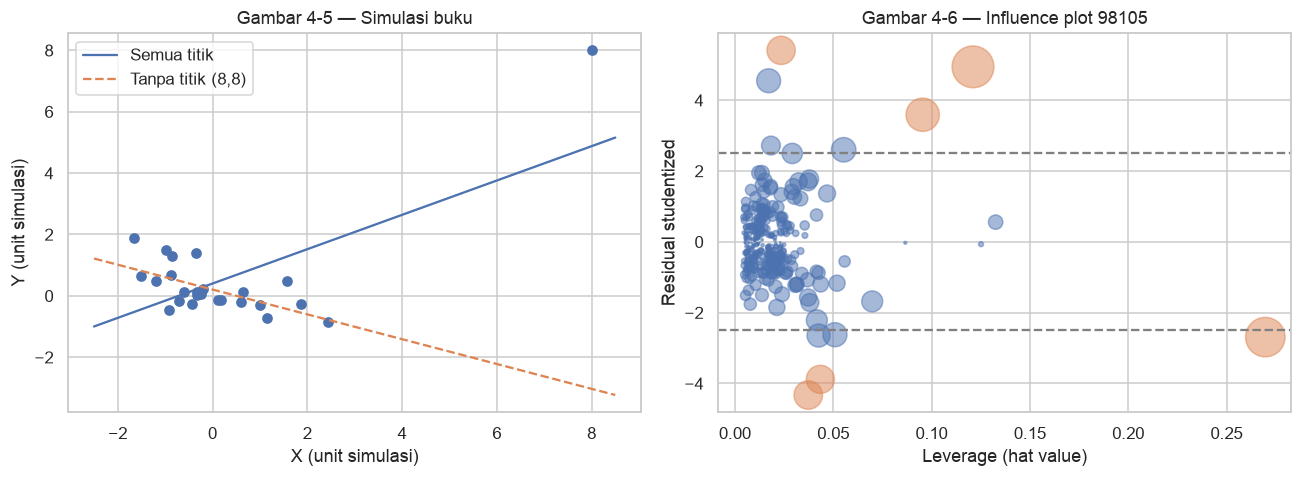

Record dikeluarkan untuk sensitivitas: 6


,semua data,"Cook D < 0,08"
const,-772549.862447,-647137.096716
SqFtTotLiving,209.602346,230.052569
SqFtLot,38.933315,33.141600
Bathrooms,2282.264145,-16131.879785
Bedrooms,-26320.268796,-22887.865318
BldgGrade,130000.099737,114870.559737


In [22]:
rs_infl=np.random.RandomState(5)
x=rs_infl.normal(size=25); y=-x/5+rs_infl.normal(size=25)
x[0]=8; y[0]=8
fig,axes=plt.subplots(1,2,figsize=(12,4.5))
axes[0].scatter(x,y)
line_x=np.linspace(-2.5,8.5,100)
for xx,yy,label,style in [(x,y,'Semua titik','-'),(x[1:],y[1:],'Tanpa titik (8,8)','--')]:
    fit=stats.linregress(xx,yy)
    axes[0].plot(line_x,fit.intercept+fit.slope*line_x,style,label=label)
axes[0].set(title='Gambar 4-5 — Simulasi buku',xlabel='X (unit simulasi)',ylabel='Y (unit simulasi)')
axes[0].legend()
cook=np.asarray(influence.cooks_distance[0])
axes[1].scatter(influence.hat_matrix_diag,studentized,s=1000*np.sqrt(cook),alpha=.5,
                c=np.where(cook>=.08,'C1','C0'))
for threshold in [-2.5,2.5]: axes[1].axhline(threshold,color='gray',ls='--')
axes[1].set(title='Gambar 4-6 — Influence plot 98105',xlabel='Leverage (hat value)',ylabel='Residual studentized')
plt.tight_layout(); plt.show()
keep=cook<.08
sensitivity=sm.OLS(local.loc[keep,target],sm.add_constant(local.loc[keep,base_features],has_constant='add')).fit()
print('Record dikeluarkan untuk sensitivitas:',int((~keep).sum()))
display(pd.DataFrame({'semua data':local_fit.params,'Cook D < 0,08':sensitivity.params}))

**Interpretasi dan catatan belajar.** Satu titik buatan mengubah arah garis pada panel kiri. Pada rumah, perubahan koefisien kamar mandi cukup besar setelah sejumlah titik influential dikeluarkan. Ini alasan memeriksa transaksi dan kestabilan model, bukan mengasumsikan semua titik oranye salah.

<a id="c4-27"></a>
## Heteroskedasticity, Non-Normality, and Correlated Errors

*Acuan: cetak 182; PDF 200. Jenis: Reproduksi grafik + SE robust tambahan.*

Heteroskedasticity berarti varians error berubah menurut X atau prediksi. Non-normality berarti bentuk error berbeda dari normal. Correlated errors terjadi pada waktu, lokasi, atau kelompok yang saling berhubungan. Ketiganya dapat memengaruhi SE/interval klasik dan membantu menemukan model yang kurang lengkap; normalitas X/Y bukan syarat OLS.

LOWESS memfit regresi lokal untuk menonjolkan pola pada scatterplot, bukan model kausal. Robust covariance HC3 dapat membantu SE terhadap heteroskedastisitas, tetapi tidak memperbaiki mean model salah atau membuat prediction interval individual otomatis valid. Durbin–Watson relevan untuk urutan waktu yang bermakna; tidak dihitung pada urutan baris transaksi arbitrer di sini.

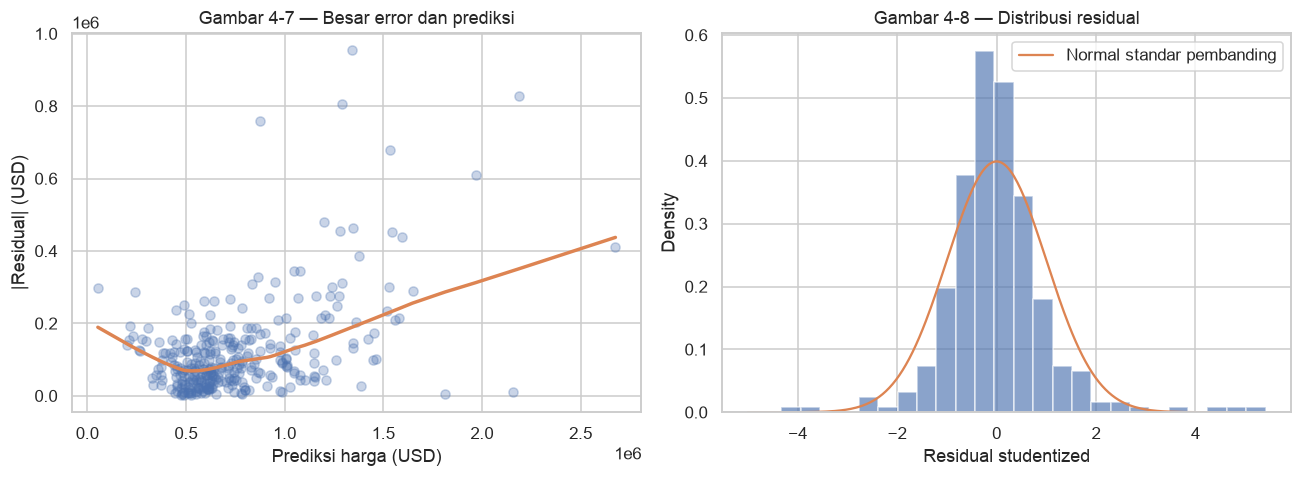

,SE klasik,SE HC3 (tambahan)
const,98277.272175,142232.916070
SqFtTotLiving,24.408055,35.305938
SqFtLot,5.329971,12.134593
Bathrooms,19983.574142,26847.732181
Bedrooms,12881.093583,15252.192410
BldgGrade,15234.122866,19861.579082


In [23]:
fig,axes=plt.subplots(1,2,figsize=(12,4.5))
sns.regplot(x=local_fit.fittedvalues,y=np.abs(local_fit.resid),lowess=True,
            scatter_kws={'alpha':.3},line_kws={'color':'C1'},ax=axes[0])
axes[0].set(title='Gambar 4-7 — Besar error dan prediksi',xlabel='Prediksi harga (USD)',ylabel='|Residual| (USD)')
axes[1].hist(studentized,bins=25,density=True,alpha=.65)
z=np.linspace(-5,5,300); axes[1].plot(z,stats.norm.pdf(z),label='Normal standar pembanding')
axes[1].set(title='Gambar 4-8 — Distribusi residual',xlabel='Residual studentized',ylabel='Density')
axes[1].legend(); plt.tight_layout(); plt.show()
robust_fit=local_fit.get_robustcov_results(cov_type='HC3')
display(pd.DataFrame({'SE klasik':local_fit.bse,'SE HC3 (tambahan)':robust_fit.bse}))

**Interpretasi dan catatan belajar.** Pola besar residual berubah sepanjang harga prediksi, dan ekor residual tidak persis normal. Interval yang memakai asumsi error homogen perlu dibaca hati-hati. Grafik ini tidak menguji independensi spasial/waktu, sehingga asumsi tersebut belum tervalidasi.

<a id="c4-28"></a>
## Partial Residual Plots and Nonlinearity

*Acuan: cetak 185; PDF 203. Jenis: Reproduksi partial residual dengan LOWESS.*

Partial residual untuk fitur j adalah $e_i+\hat b_jx_{ij}$. Grafik terhadap $x_{ij}$ memperlihatkan pola setelah kontribusi linear fitur lain diperhitungkan. Bandingkan garis komponen model dengan LOWESS partial residual; selisih sistematis dapat menyarankan bentuk nonlinear.

Partial residual plot berbeda secara konstruksi dari added-variable plot, meskipun keduanya membantu diagnostik. Kurva tidak membuktikan kausalitas; prediktor berkorelasi dan sedikit data pada ujung dapat mengganggu pembacaan. Python dan R dapat berbeda shift konstan karena centering komponen.

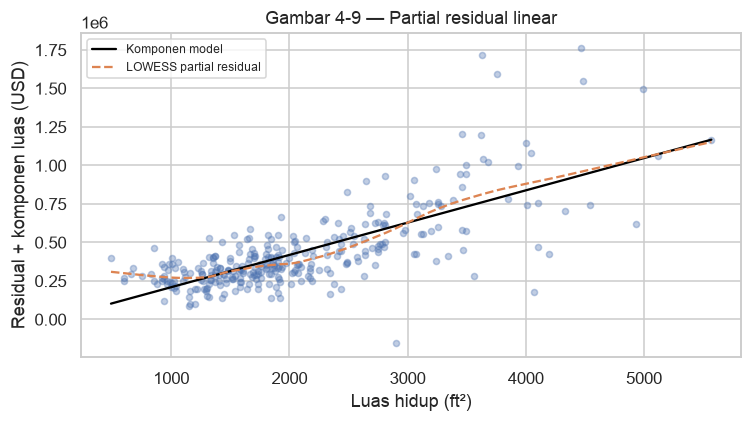

In [24]:
def component_plot(model,frame,feature,term_columns,ax,title):
    names=model.model.exog_names
    indices=[names.index(name) for name in term_columns]
    component=np.asarray(model.model.exog[:,indices]) @ np.asarray(model.params)[indices]
    partial=np.asarray(model.resid)+component
    order=np.argsort(frame[feature].to_numpy())
    smooth=sm.nonparametric.lowess(partial,frame[feature],frac=1/3)
    ax.scatter(frame[feature],partial,alpha=.35,s=16)
    ax.plot(frame[feature].to_numpy()[order],component[order],color='black',label='Komponen model')
    ax.plot(smooth[:,0],smooth[:,1],ls='--',color='C1',label='LOWESS partial residual')
    ax.set(title=title,xlabel='Luas hidup (ft²)',ylabel='Residual + komponen luas (USD)')
    ax.legend(fontsize=8)

fig,ax=plt.subplots()
component_plot(local_fit,local,'SqFtTotLiving',['SqFtTotLiving'],ax,'Gambar 4-9 — Partial residual linear')
plt.tight_layout(); plt.show()

**Interpretasi dan catatan belajar.** Kelengkungan LOWESS yang tidak mengikuti garis komponen linear memotivasi spline/polinomial. Pada luas sangat besar jumlah titik sedikit, sehingga kurva di ujung tidak boleh ditafsirkan terlalu pasti.

<a id="c4-29"></a>
## Polynomial and Spline Regression

*Acuan: cetak 187; PDF 205. Jenis: Teori.*

Hubungan target dan prediktor dapat melengkung walau model tetap linear pada parameter. Polinomial menambahkan pangkat X; spline memakai basis potongan polinomial yang tersambung mulus; GAM mengestimasi fungsi halus dengan penalti. Fleksibilitas tambahan perlu diseimbangkan dengan stabilitas dan generalisasi.

Model nonlinear pada **parameter**, misalnya beberapa bentuk eksponensial parametrik, dapat memerlukan optimasi nonlinear. Itu berbeda dari OLS dengan fitur basis nonlinear pada X. Seluruh model berikut tetap menggunakan subset 98105 agar perbandingannya konsisten.

<a id="c4-30"></a>
## Polynomial

*Acuan: cetak 188; PDF 206. Jenis: Reproduksi Python buku.*

Model kuadratik $Y=b_0+b_1X+b_2X^2+\cdots+\epsilon$ memungkinkan slope lokal berubah menjadi $b_1+2b_2X$. R `poly` default memakai basis orthogonal; Python buku memakai X dan X² mentah. Koefisien basis berbeda tetapi ruang model dan prediksi dapat sama.

Polinomial derajat tinggi dapat berosilasi dan sangat buruk saat ekstrapolasi. Contoh tetap degree=2. Helper grafik menggunakan matriks desain model, sehingga tidak perlu memprediksi fitur buatan nol yang berpotensi di luar domain spline.

,koefisien basis mentah
Intercept,-615850.841791
SqFtTotLiving,7.452134
I(SqFtTotLiving ** 2),0.038791
SqFtLot,32.559355
Bathrooms,-1435.123106
Bedrooms,-9191.944128
BldgGrade,135717.060127


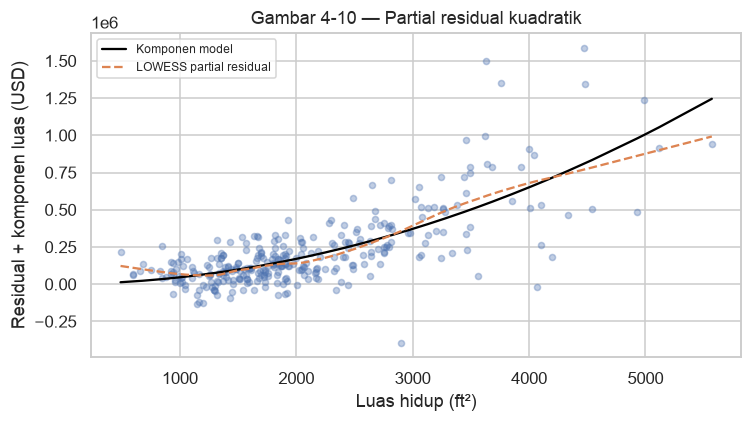

In [25]:
poly_fit=smf.ols('AdjSalePrice ~ SqFtTotLiving + I(SqFtTotLiving**2) + SqFtLot + Bathrooms + Bedrooms + BldgGrade',data=local).fit()
display(poly_fit.params.to_frame('koefisien basis mentah'))
fig,ax=plt.subplots()
component_plot(poly_fit,local,'SqFtTotLiving',['SqFtTotLiving','I(SqFtTotLiving ** 2)'] if 'I(SqFtTotLiving ** 2)' in poly_fit.model.exog_names else ['SqFtTotLiving','I(SqFtTotLiving**2)'],ax,'Gambar 4-10 — Partial residual kuadratik')
plt.tight_layout(); plt.show()

**Interpretasi dan catatan belajar.** Koefisien X² tidak dibaca sebagai tambahan harga konstan per ft². Gunakan bentuk kurva atau derivative untuk memahami perubahan lokal. Perbedaan koefisien besar terhadap output R bukan otomatis kesalahan karena basis berbeda.

<a id="c4-31"></a>
## Splines

*Acuan: cetak 189; PDF 207. Jenis: Reproduksi Python buku.*

Spline menyambung potongan polinomial pada **knots** dengan syarat kelancaran. Representasinya $f(x)=\sum_j\beta_jB_j(x)$, dengan $B_j$ fungsi basis. Contoh cubic B-spline menggunakan degree=3 dan df=6, menghasilkan tiga knot internal pada kuantil 25%, 50%, dan 75% pada data ini.

Koefisien basis individual tidak mempunyai interpretasi semudah slope linear; periksa kurva gabungan. Lebih cocok pada data latih belum membuktikan lebih baik untuk data baru. Kurva yang meningkat pada rumah sangat kecil bisa mencerminkan confounding atau noise.

Knot internal (ft²): [1410.0, 1850.0, 2570.0]


,koefisien spline dan fitur lain
Intercept,-414157.613764
"bs(SqFtTotLiving, df=6, degree=3)[0]",-199529.756362
"bs(SqFtTotLiving, df=6, degree=3)[1]",-120580.638160
"bs(SqFtTotLiving, df=6, degree=3)[2]",-71644.393597
"bs(SqFtTotLiving, df=6, degree=3)[3]",195677.894512
"bs(SqFtTotLiving, df=6, degree=3)[4]",845244.251481
"bs(SqFtTotLiving, df=6, degree=3)[5]",695545.667728
SqFtLot,33.325836
Bathrooms,-4778.207979
Bedrooms,-5778.704524


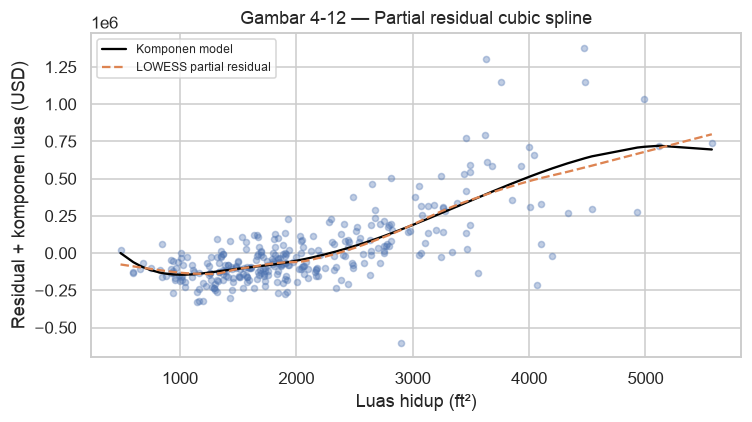

In [26]:
spline_fit=smf.ols('AdjSalePrice ~ bs(SqFtTotLiving, df=6, degree=3) + SqFtLot + Bathrooms + Bedrooms + BldgGrade',data=local).fit()
print('Knot internal (ft²):',local.SqFtTotLiving.quantile([.25,.5,.75]).to_list())
display(spline_fit.params.to_frame('koefisien spline dan fitur lain'))
spline_terms=[name for name in spline_fit.model.exog_names if name.startswith('bs(')]
fig,ax=plt.subplots()
component_plot(spline_fit,local,'SqFtTotLiving',spline_terms,ax,'Gambar 4-12 — Partial residual cubic spline')
plt.tight_layout(); plt.show()

**Interpretasi dan catatan belajar.** Spline memberi fleksibilitas lokal lebih besar daripada kuadratik. Bentuk ujung yang kurang masuk akal secara ekonomi adalah sinyal untuk meninjau data, confounder, atau derajat kelenturan, bukan langsung menganggap kurva itu hukum harga rumah.

<a id="c4-32"></a>
## Generalized Additive Models

*Acuan: cetak 192; PDF 210. Jenis: Reproduksi Python buku + ringkasan perbandingan.*

GAM menggunakan $E[Y\mid X]=\beta_0+f_1(X_1)+\cdots+f_p(X_p)$ untuk model Gaussian identitas. Contoh `LinearGAM` memasang satu smooth pada luas hidup dengan **12 spline**, dan efek linear pada empat fitur lain. Penalti mengendalikan kekasaran; `gridsearch` memilih kekuatan smoothing pada grid, bukan membuktikan pilihan knot yang optimal secara universal.

Buku menyebut otomatisasi spline; pada pyGAM implementasi ini lebih tepat dipahami sebagai pemilihan penalti smoothing pada basis yang ditetapkan. mgcv R dan pyGAM menggunakan detail optimasi/basis berbeda sehingga kurva tidak harus identik. Band 95% berikut adalah ketidakpastian efek parsial model, bukan prediction interval harga rumah individual.

Lambda hasil grid search: [[np.float64(15.848931924611142)], [np.float64(15.848931924611142)], [np.float64(15.848931924611142)], [np.float64(15.848931924611142)], [np.float64(15.848931924611142)]]
Effective degrees of freedom: 7.677249557142561


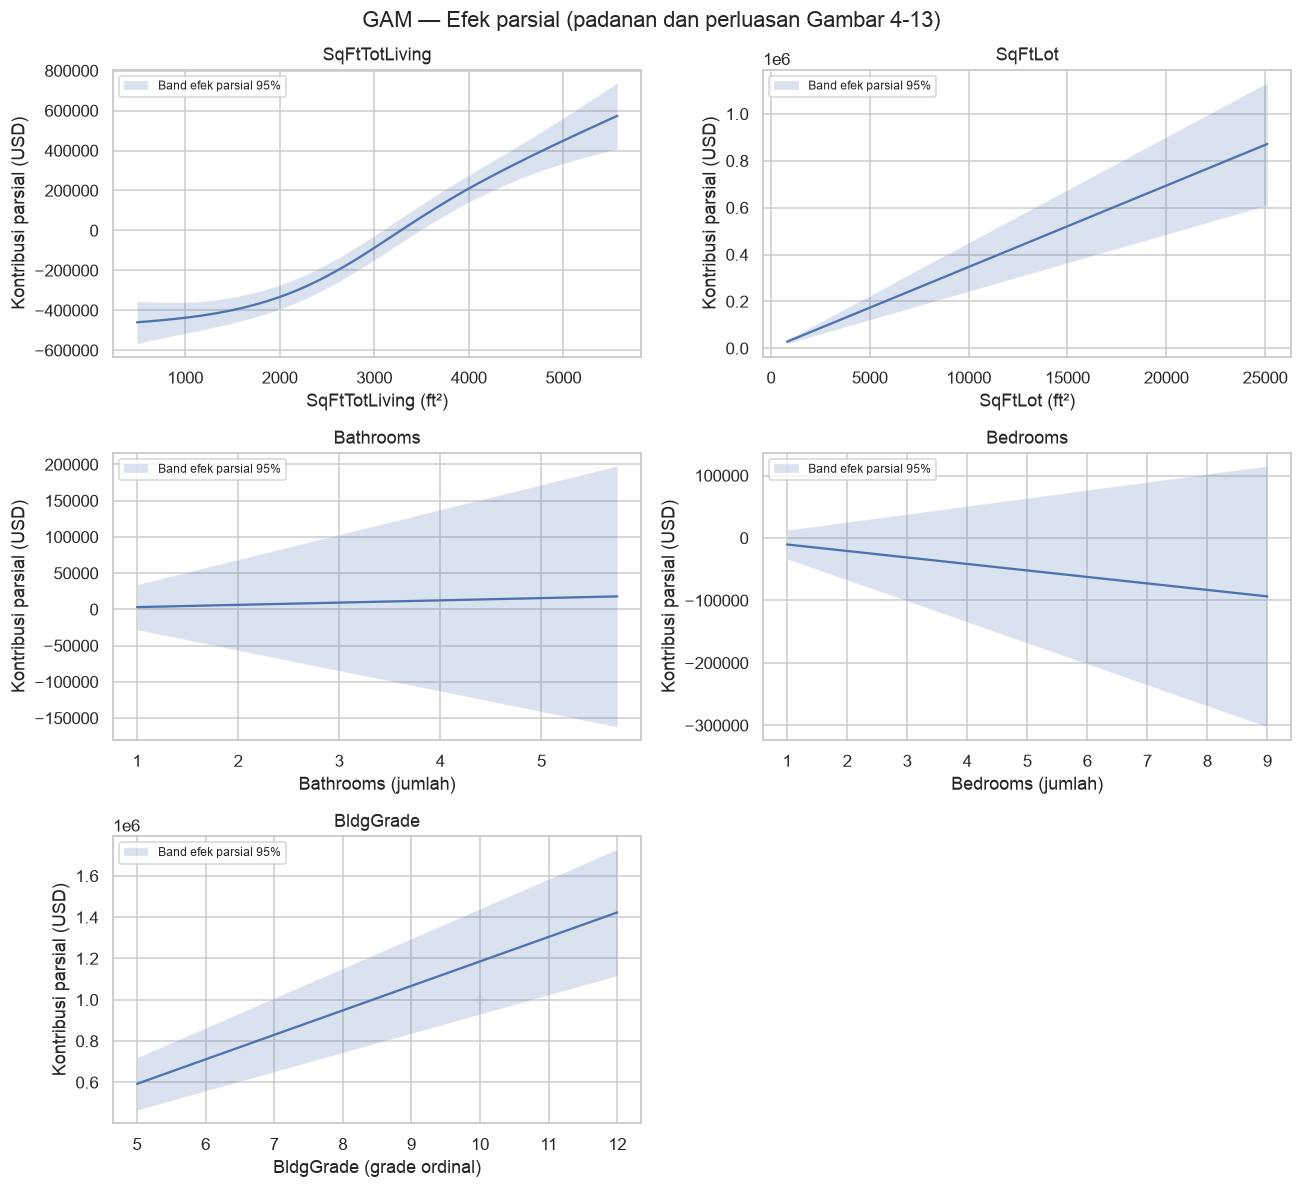

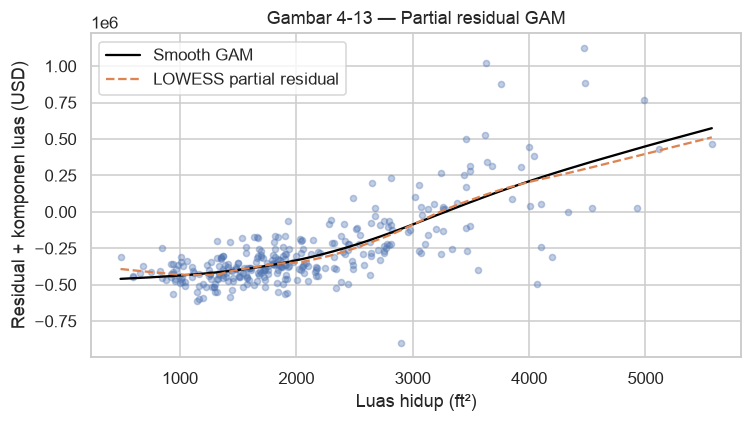

,model,RMSE train (USD),R² train,jumlah parameter / edf
0,Linear,176775.309728,0.795426,6.00000
1,Kuadratik,172241.495229,0.805785,7.00000
2,Cubic spline,168747.481944,0.813584,11.00000
3,GAM,169579.740162,0.811741,7.67725


In [27]:
gam_X=local[base_features].to_numpy(dtype=float); gam_y=local[target].to_numpy(dtype=float)
gam=LinearGAM(s(0,n_splines=12)+l(1)+l(2)+l(3)+l(4))
gam.gridsearch(gam_X,gam_y,progress=False)
print('Lambda hasil grid search:',gam.lam)
print('Effective degrees of freedom:',gam.statistics_['edof'])
fig,axes=plt.subplots(3,2,figsize=(12,11))
units=['ft²','ft²','jumlah','jumlah','grade ordinal']
for i,(feature,unit) in enumerate(zip(base_features,units)):
    ax=axes.flat[i]
    grid=gam.generate_X_grid(term=i)
    effect,interval=gam.partial_dependence(term=i,X=grid,width=.95)
    ax.plot(grid[:,i],effect,color='C0')
    ax.fill_between(grid[:,i],interval[:,0],interval[:,1],alpha=.2,label='Band efek parsial 95%')
    ax.set(title=feature,xlabel=f'{feature} ({unit})',ylabel='Kontribusi parsial (USD)')
    ax.legend(fontsize=8)
axes.flat[-1].set_visible(False)
fig.suptitle('GAM — Efek parsial (padanan dan perluasan Gambar 4-13)')
plt.tight_layout(); plt.show()
# Partial residual smooth utama untuk dibandingkan langsung dengan model sebelumnya.
gam_component=gam.partial_dependence(term=0,X=gam_X)
gam_partial=gam_y-gam.predict(gam_X)+gam_component
order=np.argsort(gam_X[:,0]); smooth=sm.nonparametric.lowess(gam_partial,gam_X[:,0],frac=1/3)
fig,ax=plt.subplots()
ax.scatter(gam_X[:,0],gam_partial,alpha=.35,s=16)
ax.plot(gam_X[order,0],gam_component[order],color='black',label='Smooth GAM')
ax.plot(smooth[:,0],smooth[:,1],ls='--',color='C1',label='LOWESS partial residual')
ax.set(title='Gambar 4-13 — Partial residual GAM',xlabel='Luas hidup (ft²)',ylabel='Residual + komponen luas (USD)')
ax.legend(); plt.tight_layout(); plt.show()
comparison=pd.DataFrame([
    {'model':name,'RMSE train (USD)':np.sqrt(np.mean(model.resid**2)),
     'R² train':model.rsquared,'jumlah parameter / edf':len(model.params)}
    for name,model in [('Linear',local_fit),('Kuadratik',poly_fit),('Cubic spline',spline_fit)]]
    +[{'model':'GAM','RMSE train (USD)':np.sqrt(mean_squared_error(gam_y,gam.predict(gam_X))),
       'R² train':r2_score(gam_y,gam.predict(gam_X)),'jumlah parameter / edf':gam.statistics_['edof']}])
display(comparison)

**Interpretasi dan catatan belajar.** Band melebar pada rentang dengan informasi lebih sedikit. Tabel fit memakai data latih dan dipakai untuk memahami fleksibilitas, bukan memilih pemenang generalisasi. Tidak ditampilkan p-value GAM sebagai bukti pasti; smoothing dipilih dari data dan inferensi tersebut memerlukan kehati-hatian.

<a id="c4-33"></a>
## Summary

*Acuan: cetak 194; PDF 212. Jenis: Teori.*

Model lung memperlihatkan arti intercept, slope, fitted value, dan residual. Model rumah menunjukkan bahwa fitur tambahan, kategori lokasi, dan interaksi mengubah interpretasi koefisien. Validasi antarproperti memberi penilaian di luar baris training; model ZipGroup dan nonlinear berikutnya tetap demonstrasi in-sample. Diagnostik menunjukkan sensitivitas terhadap transaksi tertentu, variasi error yang tidak konstan, dan kebutuhan hubungan melengkung.

**Latihan:** jelaskan tanda negatif Bedrooms sambil menyebut variabel yang ditahan tetap; bedakan leverage dan residual besar; jelaskan mengapa PI lebih lebar dari CI mean; temukan leakage jika ZipGroup dihitung sebelum CV; jelaskan mengapa spline yang lebih lentur belum tentu model terbaik.

**Batas hasil:** belum ada validasi waktu masa depan, eksperimen kausal, atau pemeriksaan independensi spasial. Dataset dan parameter contoh buku direproduksi; model ini bukan alat valuasi properti siap pakai.

**Bacaan lanjutan buku:** Shmueli tentang explanation versus prediction; James dkk. tentang resampling dan statistical learning; Hastie–Tibshirani–Friedman tentang spline/GAM. Gambar dokumen deed dan alat spline kayu dijelaskan secara konseptual dan tidak disalin.

## Referensi dan atribusi

- Peter Bruce, Andrew Bruce, Peter Gedeck. *Practical Statistics for Data Scientists: 50+ Essential Concepts Using R and Python*, edisi 2, O’Reilly, 2020. ISBN 978-1-492-07294-2, Bab 4.
- [Kode dan dataset resmi pada commit tetap](https://github.com/gedeck/practical-statistics-for-data-scientists/tree/8a6d3bb6468e979c861d4b37215e1413702dfdfa); sumber khusus: `python/code/Chapter 4*.py` dan notebook pendamping. Copyright kode upstream © 2019 Peter C. Bruce, Andrew Bruce, Peter Gedeck. Modifikasi untuk tugas: penjelasan Indonesia, seed, API, pemeriksaan hasil, dan tambahan belajar yang ditandai. Lisensi GPL-3.0: lihat [LICENSE](LICENSE).
- Bacaan lanjutan yang disebut buku dirangkum di bagian akhir bab; rujuk buku untuk bibliografi lengkap.

**Refleksi mahasiswa:** tuliskan bagian yang paling sulit, perubahan kode yang Anda coba, dan satu contoh penerapan pada Teknik Komputer. Jangan mengklaim telah melakukan eksperimen nyata dari data contoh ini.